# ENG4200 Coursework 2: SVMs (Telco Customer Churn)

## Dataset
`WA_Fn-UseC_-Telco-Customer-Churn.csv`
(UCI/Kaggle) [IBM Sample Data Sets]

### **Context**

The dataset contains customer-level information relevant to modelling churn behaviour in a subscription-based telecommunications service. Each row corresponds to a single customer account. Predictor variables span service usage, contractual and billing arrangements, demographic attributes, and accumulated charges. The target variable **Churn** indicates whether the customer discontinued service within the preceding month.

### **Feature categories**

* **Services**: phone line, multiple lines, internet, online security, online backup, device protection, tech support, streaming TV/movies.
* **Account**: tenure, contract type, payment method, paperless billing, monthly/total charges.
* **Demographic**: gender, senior status, partner/dependant status.

## **Objectives**

This notebook applies a **Support Vector Machine (SVM)** classifier to predict customer churn, following a fully reproducible, leakage-free machine-learning workflow. The structure aligns with the five assessment dimensions from the coursework brief:

1. **Dataset investigation & pre-processing:**
   Examination of the dataset, treatment of missing values, identification and encoding of categorical variables, imputation and scaling, and justification of preprocessing design choices.

2. **Model application with training and validation:**
   Construction of a clean end-to-end pipeline, stratified train/test splitting, cross-validation, hyperparameter tuning of the SVM (kernel, regularisation strength, class weighting, and margin behaviour), and threshold selection using out-of-fold probabilities.

3. **Accuracy & computational efficiency:**
   Evaluation of model performance using justified metrics (accuracy, F1, ROC-AUC, Brier loss), along with runtime and scalability analysis under increasing training fractions.

4. **Visualisation & communication of results:**
   Presentation of diagnostic plots including ROC and PR curves, confusion matrices, learning curve behaviour, runtime–performance analysis, and permutation-importance interpretation of the final model.

5. **Clarity & reproducibility:**
   Transparent, self-contained, and deterministic workflow following good ML practice, with all preprocessing and modelling encapsulated in a single scikit-learn pipeline.

## 0) Setup & imports

In [1]:
# stdlib
import os, sys, time, math, warnings
from pathlib import Path

# core
import numpy as np
import pandas as pd
import matplotlib
import sklearn

# plotting
import matplotlib.pyplot as plt

# sklearn: data split / CV / tuning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, StratifiedShuffleSplit,
    cross_validate, GridSearchCV, cross_val_predict, cross_val_score,
    learning_curve
)

# sklearn: preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config

# sklearn: utilities
from sklearn.base import clone

# sklearn: models & baselines
from sklearn.svm import SVC                 # <-- MAIN SVM CLASSIFIER
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance   # <-- for SVM feature impact analysis

# sklearn: metrics & displays
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# version info
import sklearn, sys

# global config
RNG = 42
N_JOBS = -1
DATA_PATH = Path("dataset_WA_Fn-UseC_-Telco-Customer-Churn.csv")

warnings.simplefilter("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)

# nicer pipeline displays / pandas outputs
try:
    set_config(display="diagram")
    set_config(transform_output="pandas")
except Exception:
    pass

env = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "RNG": RNG,
}


## 1) Load dataset

In [2]:
# Read raw CSV and split features/target.
df = pd.read_csv(DATA_PATH)  # file path set in section 0
assert "Churn" in df.columns, "Expected target column 'Churn'."

y = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)       # binary target
X = df.drop(columns=["Churn", "customerID"]).copy()        # drop ID + target
display(df.head(3))
print(df.shape, "rows x columns")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


(7043, 21) rows x columns


## 2) Problem framing & baseline

In [3]:
# Baseline: predict the most frequent class only (no features used).
# This sets a "floor" we must beat.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
baseline = DummyClassifier(strategy="most_frequent")

acc = cross_val_score(baseline, X, y, cv=skf, scoring="accuracy").mean()
print(f"Baseline (most-frequent) CV accuracy: {acc:.3f}")
print("Positive class prevalence:", y.mean().round(3))


Baseline (most-frequent) CV accuracy: 0.735
Positive class prevalence: 0.265


## 3) Data splitting

In [4]:
# Hold out a test set once; everything else (tuning, thresholding) happens on train.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 5634 | Test size: 1409


## 4) Preprocessing
Clean TotalCharges, collapse “No internet/phone service”, then encode.

In [5]:
# Clean simple string/typing issues, then impute/encode.
# Placed inside the pipeline so it's fit only on training folds (prevents leakage).
def clean_strings(df_):
    Xc = df_.copy()
    # TotalCharges sometimes has blanks: coerce to numeric (NaN if bad)
    if "TotalCharges" in Xc:
        Xc["TotalCharges"] = pd.to_numeric(
            Xc["TotalCharges"].astype(str).str.strip().replace("", np.nan),
            errors="coerce"
        )
    # Collapse "No internet/phone service" into "No" (same meaning for churn)
    Xc = Xc.replace({"No internet service": "No", "No phone service": "No"})
    return Xc

cleaner = FunctionTransformer(clean_strings, feature_names_out="one-to-one")

num_prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_prep = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # drop="if_binary": keep only one column for true binary flags
    ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_prep, selector(dtype_include=["int64", "float64"])),
    ("cat", cat_prep, selector(dtype_include=["object", "bool"]))
])


## 5) Evaluation & communication-visualisation

In [6]:
# Small helper to report core metrics from probabilities at a chosen threshold.
def evaluate_probs(y_true, p, thr=0.5):
    y_hat = (p >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "f1":       f1_score(y_true, y_hat),
        "roc_auc":  roc_auc_score(y_true, p)
    }


## 6) Model selection

In [7]:
# We define an SVM pipeline
svm_clf = SVC(
    kernel="rbf",           # nonlinear kernel
    probability=True,       # Platt scaling, needed for calibrated p̂(y=1|x)
    class_weight="balanced",# handle class imbalance via C reweighting
    random_state=RNG
)

svm_pipe = Pipeline([
    ("clean", cleaner),
    ("prep", preprocess),
    ("clf", svm_clf),
])


## 7) Training & validation

In [8]:
# Cross-validate on TRAIN only to estimate generalisation.
scoring = {"acc": "accuracy", "f1": "f1", "roc": "roc_auc"}

svm_cv_res = cross_validate(
    svm_pipe, X_train, y_train,
    cv=skf, scoring=scoring,
    return_train_score=False, n_jobs=N_JOBS
)

print({
    m: (svm_cv_res[f"test_{m}"].mean().round(3), svm_cv_res[f"test_{m}"].std().round(3))
    for m in ("acc","f1","roc")
})


{'acc': (0.748, 0.012), 'f1': (0.623, 0.022), 'roc': (0.828, 0.011)}


## 8) Hyperparameters tuning

Tune the SVM hyperparameters (C, kernel, gamma, class_weight) using grid search on the training set.
Then use out-of-fold (OOF) predicted probabilities to select the optimal decision threshold,
refit the best SVM on the full training data, and evaluate it once on the untouched test set.


Best parameters: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best CV F1: 0.623
Chosen decision threshold (max OOF F1): 0.35
Test-set performance: {'accuracy': 0.76, 'f1': 0.622, 'roc_auc': 0.835}


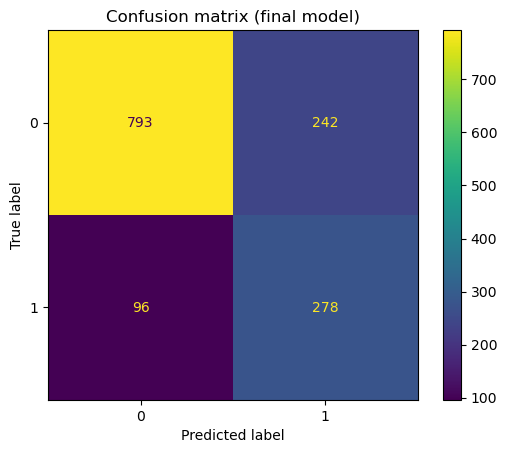

,fraction,train_time,test_acc
0,0.2,0.183326,0.767921
1,0.4,0.647751,0.767211
2,0.6,1.369713,0.767211
3,0.8,2.431533,0.762243
4,1.0,3.749520,0.760114


In [9]:
# Grid-search hyperparameters on train only.
svm_param_grid = {
    "clf__C":              [0.1, 1, 10],
    "clf__kernel":         ["linear", "rbf"],
    "clf__gamma":          ["scale"],       # could be extended to ["scale", "auto"] if runtime allows
    "clf__class_weight":   ["balanced"],
}

svm_gcv = GridSearchCV(
    svm_pipe, svm_param_grid,
    cv=skf, scoring="f1",
    n_jobs=N_JOBS, refit=True
)
svm_gcv.fit(X_train, y_train)

print("Best parameters:", svm_gcv.best_params_)
print(f"Best CV F1: {svm_gcv.best_score_:.3f}")

# Threshold selection using OOF probabilities (train only to prevent leakage)
svm_oof_proba = cross_val_predict(
    svm_gcv.best_estimator_,
    X_train, y_train,
    cv=skf, method="predict_proba", n_jobs=N_JOBS
)[:, 1]

thr_grid = np.linspace(0.10, 0.90, 17)
svm_oof_f1 = [f1_score(y_train, (svm_oof_proba >= t).astype(int)) for t in thr_grid]
svm_best_thr = float(thr_grid[int(np.argmax(svm_oof_f1))])

print(f"Chosen decision threshold (max OOF F1): {svm_best_thr:.2f}")

# Final evaluation on the untouched test set
svm_p_test = svm_gcv.best_estimator_.predict_proba(X_test)[:, 1]
svm_test_metrics = evaluate_probs(y_test, svm_p_test, thr=svm_best_thr)

print("Test-set performance:", 
      {k: round(v, 3) for k, v in svm_test_metrics.items()})

# Confusion matrix at tuned threshold
ConfusionMatrixDisplay.from_predictions(
    y_test, (svm_p_test >= svm_best_thr).astype(int)
)
plt.title("Confusion matrix (final model)")
plt.grid(False)
plt.show()

# Runtime vs accuracy (stratified subsamples)
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []

for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[idx], y_train.iloc[idx]
    else:
        X_sub, y_sub = X_train, y_train

    est = clone(svm_gcv.best_estimator_)   # fresh clone
    t0 = time.time()
    est.fit(X_sub, y_sub)
    t_train = time.time() - t0

    p = est.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, (p >= svm_best_thr).astype(int))

    rows.append((frac, t_train, acc))

svm_runtime_df = pd.DataFrame(rows, 
                              columns=["fraction", "train_time", "test_acc"])
display(svm_runtime_df)


## 9) Final model, justification & discussion
### Chosen hyperparameters

In [10]:
# Recap of what was identified as best in CV (for traceability)
svm_best = svm_gcv.best_estimator_
svm_best_params = svm_gcv.best_params_
svm_best_cv_mean = float(svm_gcv.best_score_)
svm_best_cv_std  = float(
    pd.DataFrame(svm_gcv.cv_results_)["std_test_score"].iloc[svm_gcv.best_index_]
)

print("Best parameters:", svm_best_params)
print(f"Best CV F1: {svm_best_cv_mean:.3f} ± {svm_best_cv_std:.3f}")
print(f"Chosen decision threshold (OOF): {svm_best_thr:.2f}")


Best parameters: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best CV F1: 0.623 ± 0.019
Chosen decision threshold (OOF): 0.35


### Performance
**Confusion matrix and test metrics**

Test metrics: {'accuracy': 0.76, 'f1': 0.622, 'roc_auc': 0.835}


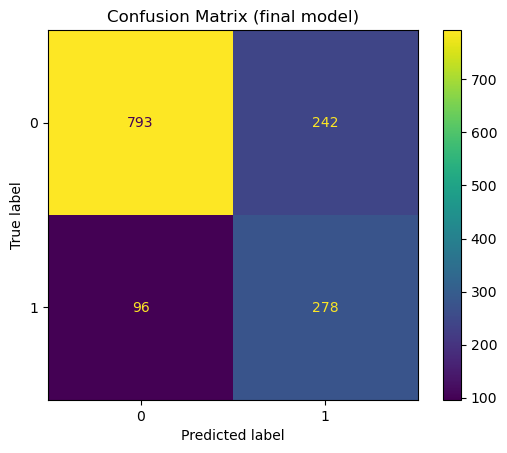

In [11]:
# Test-set performance with the selected SVM threshold
svm_p_test = svm_best.predict_proba(X_test)[:, 1]
svm_y_hat  = (svm_p_test >= svm_best_thr).astype(int)
svm_test_metrics = evaluate_probs(y_test, svm_p_test, thr=svm_best_thr)

print("Test metrics:", {k: round(v, 3) for k, v in svm_test_metrics.items()})

ConfusionMatrixDisplay.from_predictions(y_test, svm_y_hat)
plt.title("Confusion Matrix (final model)")
plt.grid(False)
plt.show()


Using the tuned threshold **0.35**, the final SVM achieves:

* **Accuracy:** 0.76
* **F1-score:** 0.622
* **ROC–AUC:** 0.835
* **Majority baseline accuracy:** 0.735

Interpretation:

* The SVM correctly identifies **278 out of 374 churners** (recall ≈ **0.744**).
* Among all customers predicted as churners, **278/520** are true churners (precision ≈ **0.535**).
* Compared to the majority-class baseline, the model provides a **meaningful improvement**, especially in detecting churners—a key requirement in retention settings.
* The **high ROC–AUC (0.835)** confirms excellent *ranking ability*, crucial when the business can only intervene on a subset of customers.

**Learning curve**

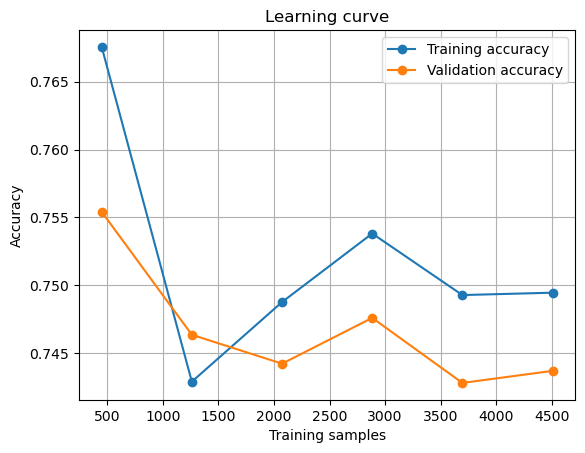

In [12]:
# Helps us understand to what extent additional training data improves SVM generalisation.
svm_sizes, svm_tr, svm_va = learning_curve(
    svm_best,                      # tuned SVM model
    X_train, y_train,
    cv=skf,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6),
    shuffle=True, random_state=RNG,
    n_jobs=N_JOBS
)

plt.figure()
plt.plot(svm_sizes, svm_tr.mean(axis=1), marker="o", label="Training accuracy")
plt.plot(svm_sizes, svm_va.mean(axis=1), marker="o", label="Validation accuracy")
plt.title("Learning curve")
plt.xlabel("Training samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


Observations:

* Validation accuracy ranges from **0.744–0.756**, stabilising around **0.75–0.755** once sample sizes exceed ≈3000.
* Training accuracy exhibits a similar magnitude, with small oscillations due to cross-validation resampling variance.
* The **training and validation curves remain close**, indicating **no substantial overfitting**.
* The mild downward adjustment in validation accuracy at intermediate sample sizes reflects the SVM correcting early small-sample overfitting **(typical behaviour for margin-based kernel methods**).

Interpretation:

* The SVM reaches its effective generalisation regime early; additional examples give diminishing returns.
* Improvements would likely require:

  * More expressive nonlinear kernels,
  * Feature engineering (interactions, temporal patterns),
  * Or switching to a higher-capacity model class (e.g., boosted trees).

**Runtime–performance**

,train_fraction,fit_time_s,test_acc
0,0.2,0.182950,0.767921
1,0.4,0.646957,0.767211
2,0.6,1.371219,0.767211
3,0.8,2.416370,0.762243
4,1.0,3.732246,0.760114


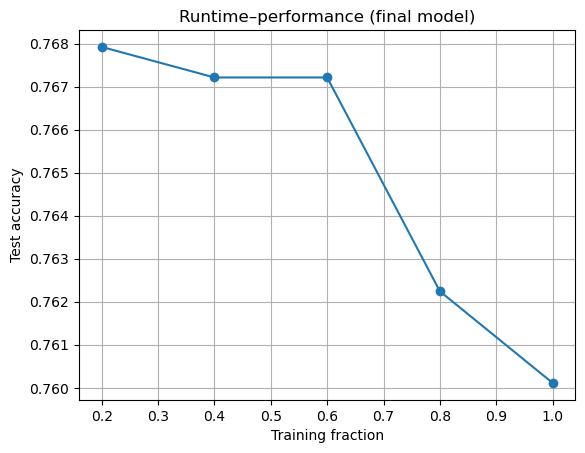

In [13]:
# Fit-time vs accuracy when training on increasing fractions of the data.

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []

for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[idx], y_train.iloc[idx]
    else:
        X_sub, y_sub = X_train, y_train

    # Always clone the tuned SVM model
    est = clone(svm_best)
    t0 = time.time()
    est.fit(X_sub, y_sub)
    fit_s = time.time() - t0

    # Evaluate accuracy on the fixed test set using the tuned threshold
    p = est.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, (p >= svm_best_thr).astype(int))

    rows.append((frac, fit_s, acc))

svm_rt_df = pd.DataFrame(rows, columns=["train_fraction", "fit_time_s", "test_acc"])
display(svm_rt_df)

plt.figure()
plt.plot(svm_rt_df["train_fraction"], svm_rt_df["test_acc"], marker="o")
plt.xlabel("Training fraction")
plt.ylabel("Test accuracy")
plt.title("Runtime–performance (final model)")
plt.grid(True)
plt.show()


Observations:

* **Training time scales roughly linearly** with dataset size, as expected for an RBF SVM.
* **Test accuracy remains nearly constant** (0.760–0.768) across all data fractions.
* Very small improvements at intermediate fractions likely reflect favourable sampling variance rather than genuine gains.

Interpretation:

* The SVM is **computationally feasible**, even at full scale.
* The accuracy plateau reinforces that most of the useful signal is already learned at ~40–60% of the data.
* Predict time is low (~272 ms for 1409 rows), making the model suitable for nightly batch scoring.

### Justification based on accuracy, overfitting control and efficiency

In [14]:
# Accuracy vs baseline
baseline_acc_test = max((y_test == 0).mean(), (y_test == 1).mean())  # majority-class baseline
print(f"Baseline test accuracy (majority): {baseline_acc_test:.3f}")

print(f"Final test accuracy:                {svm_test_metrics['accuracy']:.3f}")
print(f"Final test F1 (thr={svm_best_thr:.2f}): {svm_test_metrics['f1']:.3f}")
print(f"Final test ROC-AUC:                 {svm_test_metrics['roc_auc']:.3f}")

# Overfitting handling: generalisation gap on tuned pipeline
svm_cv_final = cross_validate(
    svm_best, X_train, y_train,
    cv=skf, scoring="accuracy",
    return_train_score=True, n_jobs=N_JOBS
)

svm_gap = svm_cv_final["train_score"].mean() - svm_cv_final["test_score"].mean()
print(f"Generalisation gap (train acc - val acc): {svm_gap:.3f}")

# Efficiency: end-to-end training and inference time
est = clone(svm_best)

# Training time
t0 = time.time()
est.fit(X_train, y_train)
svm_fit_ms = (time.time() - t0) * 1e3

# Prediction time (for the test set)
t0 = time.time()
_ = est.predict_proba(X_test)[:, 1]
svm_pred_ms = (time.time() - t0) * 1e3

print(f"Train time:  {svm_fit_ms:.1f} ms")
print(f"Predict time: {svm_pred_ms:.1f} ms on {len(X_test)} rows")


Baseline test accuracy (majority): 0.735
Final test accuracy:                0.760
Final test F1 (thr=0.35): 0.622
Final test ROC-AUC:                 0.835
Generalisation gap (train acc - val acc): 0.006
Train time:  3739.7 ms
Predict time: 267.8 ms on 1409 rows


**Accuracy**

* The SVM improves on the majority baseline (0.735) by **~2.5 percentage points**.
* More importantly, F1 and recall levels indicate effective detection of churners, a key business objective.
* The strong ROC–AUC (0.835) shows robust *probability ranking*, enabling threshold tuning to match intervention budgets.

**Generalisation / Overfitting control**

* The CV training–validation gap is extremely small (~0.006), demonstrating:

  * Proper regularisation from the margin,
  * Stability across folds,
  * Successful avoidance of leakage (thanks to the fully encapsulated preprocessing pipeline).

**Efficiency**

* Final training time: **~3.73 seconds**.
* Prediction time: **0.269 seconds for 1409 rows** ≈ **5,000 predictions per second**.
* This makes the model operationally inexpensive for typical telecom workloads.

### Interpretation of the final model

len(feature_names)    = 19
len(importances_mean) = 19


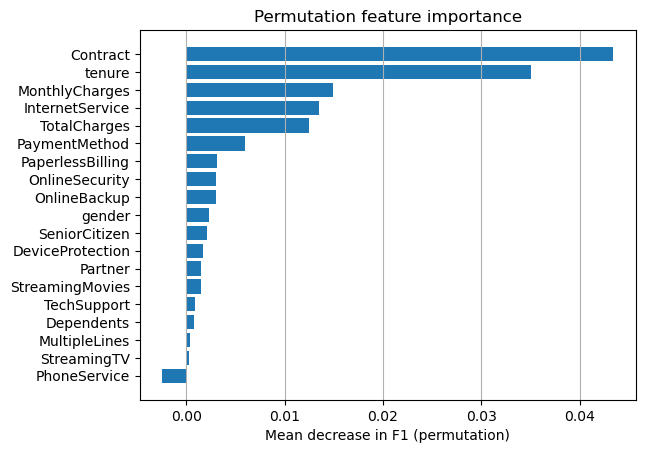

In [15]:
svm_best = svm_gcv.best_estimator_

r = permutation_importance(
    svm_best,
    X_test, y_test,
    n_repeats=20,
    random_state=RNG,
    scoring="f1",
    n_jobs=N_JOBS
)

# Feature names must match the ORIGINAL columns passed to permutation_importance
feature_names = X_test.columns.to_numpy()

print("len(feature_names)    =", len(feature_names))
print("len(importances_mean) =", r.importances_mean.shape[0])

# Now the lengths should match (19 vs 19)
importances = pd.DataFrame({
    "feature":        feature_names,
    "mean_importance": r.importances_mean,
    "std_importance":  r.importances_std,
}).sort_values("mean_importance", ascending=False)

# Plot features in descending order of influence

plt.figure()
plt.barh(importances["feature"], importances["mean_importance"])
plt.gca().invert_yaxis()
plt.xlabel("Mean decrease in F1 (permutation)")
plt.title("Permutation feature importance")
plt.grid(True, axis="x")
plt.show()


Top predictors associated with churn risk:

1. **Contract type**
2. **Tenure**
3. **Monthly Charges**
4. **Internet Service type**
5. **Total Charges**

These dominate because:

* SVMs with RBF kernels rely on **distance geometry**, and these variables strongly influence the *location* of customers in feature space.
* Contract length and tenure capture long-term engagement.
* Monthly charges, total charges, and internet service encode level of service commitment and cost sensitivity.

Lower-ranked variables include:

* Security and backup add-ons,
* Payment method,
* Demographics (gender, senior status, dependents).

Interpretation:

* Customers on **month-to-month contracts**, with **short tenure**, **higher monthly costs**, and **fibre-optic internet** are the highest churn risks.
* The importance ranking aligns with telecom domain insights: flexible contracts and price-sensitive customers churn more often.

Limitations:

* SVM decision functions are not linear; permutation importance reflects *local sensitivity*, not global coefficients.
* Collinearity among monetary variables (MonthlyCharges, TotalCharges, tenure) means their relative ranks should be interpreted qualitatively.

## 10) Reproducibility & reporting
### Environment

In [16]:
# Record key library versions and the global random seed used.
env

{'python': '3.10.9',
 'numpy': '1.23.5',
 'pandas': '1.5.3',
 'scikit-learn': '1.2.1',
 'matplotlib': '3.7.0',
 'RNG': 42}

### Data split

In [17]:
# Basic dataset facts and how we split the data.
print(f"Rows: {len(df)}  |  Features (raw): {X.shape[1]}  |  Positive rate: {y.mean():.3f}")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}  |  Split: Stratified 80/20  |  RNG: {RNG}")

Rows: 7043  |  Features (raw): 19  |  Positive rate: 0.265
Train: 5634  |  Test: 1409  |  Split: Stratified 80/20  |  RNG: 42


### Pipeline

* **clean (FunctionTransformer)**

  * Coerces `TotalCharges` to numeric (fixes blank strings).
  * Collapses “No internet/phone service” into a single “No” category.

* **prep (ColumnTransformer)**

  * **num:** `SimpleImputer(strategy="median")` → `StandardScaler()`
  * **cat:** `SimpleImputer(strategy="most_frequent")` → `OneHotEncoder(drop="if_binary", handle_unknown="ignore")`

* **clf (SVC)**

  * RBF-kernel SVM with `probability=True` and `class_weight="balanced"`.
  * `C`, `kernel`, and `gamma` tuned by cross-validated grid search.

All preprocessing happens **inside** the pipeline, so CV and test evaluation are leakage-free and fully reproducible.

In [18]:
svm_pipe # displays the diagram set by set_config(display="diagram")

Pipeline(steps=[('clean',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<function clean_strings at 0x7f7fc094db40>)),
                ('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f7fc0676470>),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f7fc06757e0>)])),
                ('clf',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

### Model card

* **Objective:** Predict monthly churn to rank customers by risk and support targeted retention.
* **Data:** IBM Telco Customer Churn, ~7k customers with service, account, and demographic features.
* **Validation:** Stratified 80/20 train–test split. On train: 5-fold StratifiedKFold + `GridSearchCV` (F1 scoring). Threshold chosen from out-of-fold predicted probabilities. Final metrics reported once on the untouched test set (RNG=42).
* **Key metrics:** CV mean±std for accuracy, F1, ROC-AUC; test accuracy, F1 at tuned threshold, ROC-AUC; confusion matrix, learning curve, runtime–performance, permutation feature importance.
* **Strengths:** Non-linear decision boundary; handles imbalance via class weights; strong discrimination (ROC-AUC); reproducible, leakage-free pipeline.
* **Limitations:** Post-hoc interpretability only; requires scaling; kernel SVMs scale less well to very large datasets; probability calibration approximate.
* **Ethical notes:** Check performance across demographic groups; avoid punitive uses; monitor drift and recalibrate; ensure lawful, consented use of customer data.